In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
import numpy as np
import pandas as pd
import seaborn as sns
import os

In [9]:
csv_path = r'C:\Users\ASUS\Desktop\3y\S2\machine learning\Project\Local\Data\api_submission_v3.csv'
df = pd.read_csv(csv_path)

print(f"Loaded {len(df)} submissions.")
df[['amphitheatre', 'latitude_mean', 'longitude_mean', 'is_outside']].head()

Loaded 7367 submissions.


,amphitheatre,latitude_mean,longitude_mean,is_outside
0,Amphi 3,36.687824,2.867150,False
1,lab 8,36.688127,2.867512,True
2,School entry,36.688729,2.865596,True
3,Amphi 4,36.688630,2.866750,False
4,room,36.688630,2.866750,True


In [4]:
df = df[['id','amphitheatre', 'latitude_mean', 'longitude_mean', 'is_outside']]

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7367 entries, 0 to 7366
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              7367 non-null   int64  
 1   amphitheatre    7367 non-null   object 
 2   latitude_mean   7367 non-null   float64
 3   longitude_mean  7367 non-null   float64
 4   is_outside      7367 non-null   bool   
dtypes: bool(1), float64(2), int64(1), object(1)
memory usage: 237.5+ KB


keep only classes that hass more than 100 examples 

In [10]:
# Standardize amphitheatretheater labels
# Keep amphitheatre 1-8, change everything else to "Outside"
valid_amphis = [f"Amphi {i}" for i in range(1, 9)]  # Amphi 1 through Amphi 8

print("Before standardization:")
print(f"Unique amphitheater labels: {df['amphitheatre'].unique()}")
print(f"Label counts:\n{df['amphitheatre'].value_counts()}")

# Replace non-standard labels with "Outside"
df['amphitheatre'] = df['amphitheatre'].apply(lambda x: x if x in valid_amphis else "Outside")

print("\nAfter standardization:")
print(f"Unique amphitheater labels: {df['amphitheatre'].unique()}")
print(f"Label counts:\n{df['amphitheatre'].value_counts()}")

# Verify we have the expected classes
expected_classes = valid_amphis + ["Outside"]
actual_classes = sorted(df['amphitheatre'].unique())
print(f"\nExpected classes: {expected_classes}")
print(f"Actual classes: {actual_classes}")
print(f"Classes match: {set(expected_classes) == set(actual_classes)}")

Before standardization:
Unique amphitheater labels: ['Amphi 3' 'lab 8' 'School entry' 'Amphi 4' 'room' 'end tarek' 'nasro '
 'mazalni end tarek' 'dorm' 'outside' 'Amphi 5' 'Amphi 1' 'Outside'
 'Amphi 7' 'Amphi 2' 'Hfgnffn' 'Amphi 6' 'Nasro' 'Mdpres end tarek'
 'SkillnTell Spot ' 'Spot ' 'maalma3' "Salle d'études" 'Salle d’études'
 'Amphi 3 door 2 ' 'Amphi 3 door 1 ' 'AMPHI8' 'Amphi 8' 'Hall' 'tuto23'
 'Dorms']
Label counts:
amphitheatre
Amphi 2              2565
Amphi 5              1227
Amphi 6               774
Amphi 4               741
Outside               658
Amphi 1               604
Amphi 3               318
Amphi 7               122
Nasro                 100
Mdpres end tarek       46
maalma3                33
Dorms                  21
SkillnTell Spot        20
Salle d'études         20
Amphi 8                20
Spot                   10
Hfgnffn                10
Salle d’études         10
Amphi 3 door 2         10
AMPHI8                 10
Amphi 3 door 1         10
Hall         

In [11]:
counts = df['amphitheatre'].value_counts()

valid_classes = counts[counts > 100].index

df = df[df['amphitheatre'].isin(valid_classes)]

In [12]:
df['amphitheatre'].value_counts()

amphitheatre
Amphi 2    2565
Amphi 5    1227
Outside     996
Amphi 6     774
Amphi 4     741
Amphi 1     604
Amphi 3     318
Amphi 7     122
Name: count, dtype: int64

In [13]:
df_a2 = df[df['amphitheatre'] == 'Amphi 2'].copy()

In [14]:
X = df_a2[['latitude_mean', 'longitude_mean']].values

In [15]:
from sklearn.cluster import DBSCAN

db = DBSCAN(
    eps=0.00025,   # ~20–30 meters (adjust if needed)
    min_samples=15 # core density threshold
)

df_a2['cluster'] = db.fit_predict(X)

In [16]:
df_a2['cluster'].value_counts()

cluster
 0    2417
 1      60
-1      25
 3      24
 4      22
 2      17
Name: count, dtype: int64

In [19]:
# find largest cluster (excluding noise -1)
valid_clusters = df_a2[df_a2['cluster'] != -1]['cluster']

main_cluster = valid_clusters.value_counts().idxmax()

df_a2_clean = df_a2[df_a2['cluster'] == main_cluster].copy()
df_a2_outliers = df_a2[df_a2['cluster'] != main_cluster].copy()

In [17]:
amphi_corners = {
    "Amphi 1/5": [
        (36.6882320, 2.8666535),  # top-left
        (36.6882443, 2.8668060),  # top-right
        (36.6880865, 2.8668389),  # bottom-right
        (36.6880720, 2.8666538),  # bottom-left
    ],
    "Amphi 2/6": [
        (36.6882129, 2.8663997),  # top-left
        (36.6882193, 2.8665428),  # top-right
        (36.6880268, 2.8665894),  # bottom-right
        (36.6880123, 2.8663926),  # bottom-left
    ],
    "Amphi 3/7": [
        (36.6881935, 2.8661324),  # top-left
        (36.6881954, 2.8662759),  # top-right
        (36.6880368, 2.8663122),  # bottom-right
        (36.6880252, 2.8661318),  # bottom-left
    ],
    "Amphi 4/8": [
        (36.6881693, 2.8658652),  # top-left
        (36.6881817, 2.8660131),  # top-right
        (36.6880179, 2.8660490),  # bottom-right
        (36.6880075, 2.8658649),  # bottom-left
    ],
}

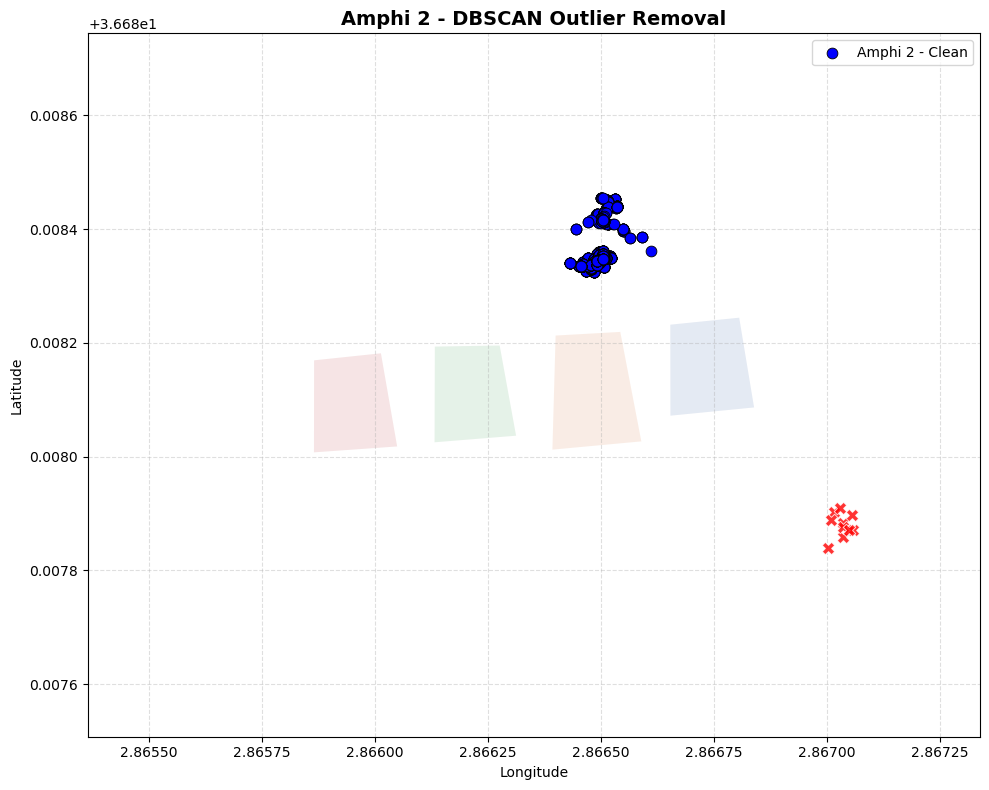

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

df_plot_out = df_a2_outliers.copy()

df_plot_out['latitude_mean'] += np.random.normal(0, 0.00002, len(df_plot_out))
df_plot_out['longitude_mean'] += np.random.normal(0, 0.00002, len(df_plot_out))

fig, ax = plt.subplots(figsize=(10, 8))

# ======================
# polygons
# ======================
patches = []
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for (name, corners), color in zip(amphi_corners.items(), colors):
    xy = np.array([(lon, lat) for lat, lon in corners])
    poly = Polygon(xy, closed=True)
    patches.append(poly)

ax.add_collection(PatchCollection(patches, facecolors=colors, alpha=0.15, zorder=1))

# ======================
# clean points
# ======================
sns.scatterplot(
    data=df_a2_clean,
    x='longitude_mean',
    y='latitude_mean',
    color='blue',
    label='Amphi 2 - Clean',
    s=60,
    edgecolor='black',
    ax=ax,
    zorder=3
)

# ======================
# outliers
# ======================
sns.scatterplot(
    data=df_plot_out,
    x='longitude_mean',
    y='latitude_mean',
    color='red',
    marker='X',
    s=80,
    alpha=0.8,
    ax=ax,
    zorder=6
)

# ======================
# formatting
# ======================
ax.set_title("Amphi 2 - DBSCAN Outlier Removal", fontsize=14, fontweight='bold')
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, linestyle="--", alpha=0.4)
all_lats = [c[0] for corners in amphi_corners.values() for c in corners]
all_lons = [c[1] for corners in amphi_corners.values() for c in corners]

ax.set_xlim(min(all_lons) - 0.0005, max(all_lons) + 0.0005)
ax.set_ylim(min(all_lats) - 0.0005, max(all_lats) + 0.0005)

plt.legend()
plt.tight_layout()
plt.show()

In [21]:
print(df_a2_clean.shape)
print(df_a2_outliers.shape)

(2417, 25)
(148, 25)


In [22]:
df_a2_clean = df_a2[df_a2['cluster'] == 0].copy()
df_a2_noise = df_a2[df_a2['cluster'] != 0].copy()

In [23]:
print(df_a2_clean['cluster'].value_counts())

cluster
0    2417
Name: count, dtype: int64


In [24]:

clusters = sorted(df_a2_clean['cluster'].unique())

for cl in sorted(df_a2_clean['cluster'].unique()):
    print(cl, df_a2_clean[df_a2_clean['cluster'] == cl].shape)


0 (2417, 25)


Cluster 0 -> (2417, 25)


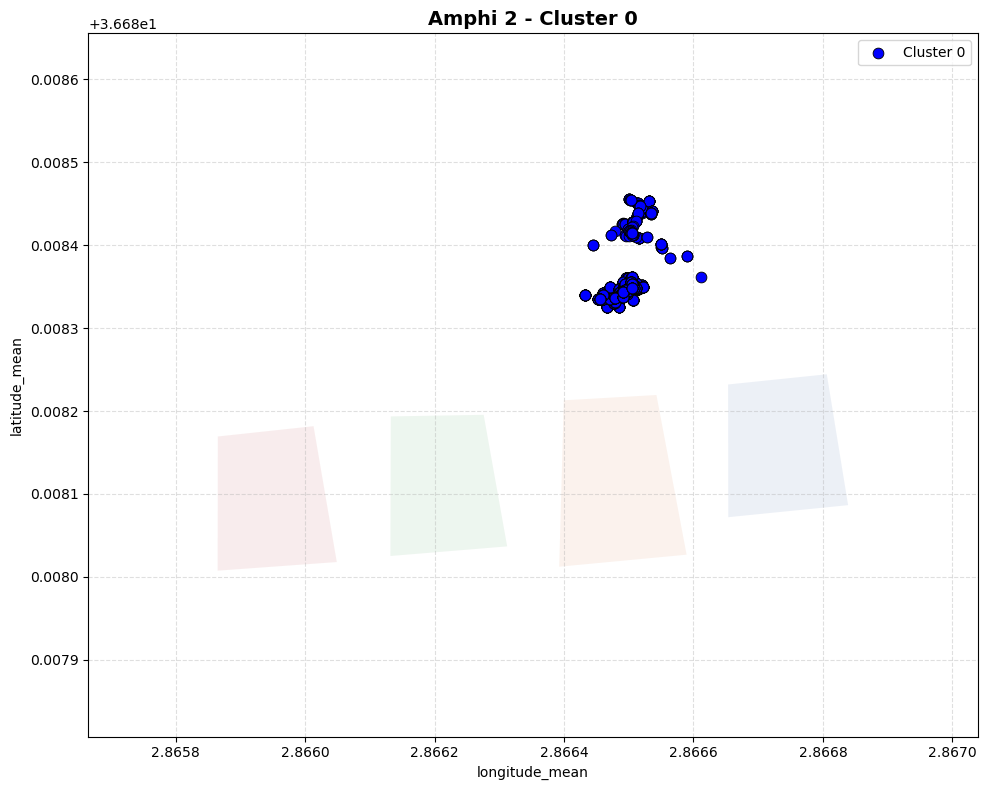

In [25]:

from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

# Keep only valid numeric points before plotting
df_a2_clean = df_a2_clean.copy()
df_a2_clean['cluster'] = pd.to_numeric(df_a2_clean['cluster'], errors='coerce')
df_a2_clean['longitude_mean'] = pd.to_numeric(df_a2_clean['longitude_mean'], errors='coerce')
df_a2_clean['latitude_mean'] = pd.to_numeric(df_a2_clean['latitude_mean'], errors='coerce')
df_a2_clean = df_a2_clean.dropna(subset=['cluster', 'longitude_mean', 'latitude_mean'])
df_a2_clean['cluster'] = df_a2_clean['cluster'].astype(int)

clusters = sorted(df_a2_clean['cluster'].unique())

for cl in clusters:
    subset = df_a2_clean[df_a2_clean['cluster'] == cl].copy()

    print(f"Cluster {cl} -> {subset.shape}")  # DEBUG

    fig, ax = plt.subplots(figsize=(10, 8))

    # ======================
    # polygons
    # ======================
    patches = []
    colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

    for (name, corners), color in zip(amphi_corners.items(), colors):
        xy = np.array([(lon, lat) for lat, lon in corners])
        poly = Polygon(xy, closed=True)
        patches.append(poly)

    ax.add_collection(
        PatchCollection(patches, facecolors=colors, alpha=0.10, zorder=0)
    )

    # ======================
    # scatter
    # ======================
    sns.scatterplot(
        data=subset,
        x='longitude_mean',
        y='latitude_mean',
        color='blue',
        s=60,
        edgecolor='black',
        ax=ax,
        label=f'Cluster {cl}',
        zorder=3
    )

    # ======================
    # AXIS (include polygons + cluster points)
    # ======================
    poly_lats = [c[0] for corners in amphi_corners.values() for c in corners]
    poly_lons = [c[1] for corners in amphi_corners.values() for c in corners]

    data_lats = subset['latitude_mean'].to_list()
    data_lons = subset['longitude_mean'].to_list()

    all_lats = poly_lats + data_lats
    all_lons = poly_lons + data_lons

    lat_pad = 0.0002
    lon_pad = 0.0002
    ax.set_xlim(min(all_lons) - lon_pad, max(all_lons) + lon_pad)
    ax.set_ylim(min(all_lats) - lat_pad, max(all_lats) + lat_pad)

    ax.set_title(f"Amphi 2 - Cluster {cl}", fontsize=14, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

In [26]:
# Keep only cluster 1 instances
df_a2_clean = df_a2[df_a2['cluster'] == 0].copy()
# Optional: keep all non-cluster-1 points (including noise) for comparison
df_a2_noise = df_a2[df_a2['cluster'] != 0].copy()

In [25]:
df_a2_clean.columns

Index(['id', 'amphitheatre', 'latitude_mean', 'longitude_mean', 'is_outside',
       'cluster'],
      dtype='object')

In [28]:
df_a2_clean['amphitheatre'].value_counts()

amphitheatre
Amphi 2    2417
Name: count, dtype: int64

# outside outlier detection and removing 

In [29]:
# Build a dataframe with only outside examples
outside_mask = (
    df['is_outside']
    .astype(str)
    .str.strip()
    .str.lower()
    .isin(['true', '1', 'yes'])
)

df_outside = df.loc[outside_mask, ['id', 'amphitheatre', 'latitude_mean', 'longitude_mean', 'is_outside']].copy()

df_outside['latitude_mean'] = pd.to_numeric(df_outside['latitude_mean'], errors='coerce')
df_outside['longitude_mean'] = pd.to_numeric(df_outside['longitude_mean'], errors='coerce')
df_outside = df_outside.dropna(subset=['latitude_mean', 'longitude_mean'])

print(f"Outside examples: {len(df_outside)}")
df_outside.head()

Outside examples: 996


,id,amphitheatre,latitude_mean,longitude_mean,is_outside
1,3,Outside,36.688127,2.867512,True
2,4,Outside,36.688729,2.865596,True
4,6,Outside,36.688630,2.866750,True
5,7,Outside,36.725914,2.999500,True
6,122,Outside,36.685800,2.865860,True


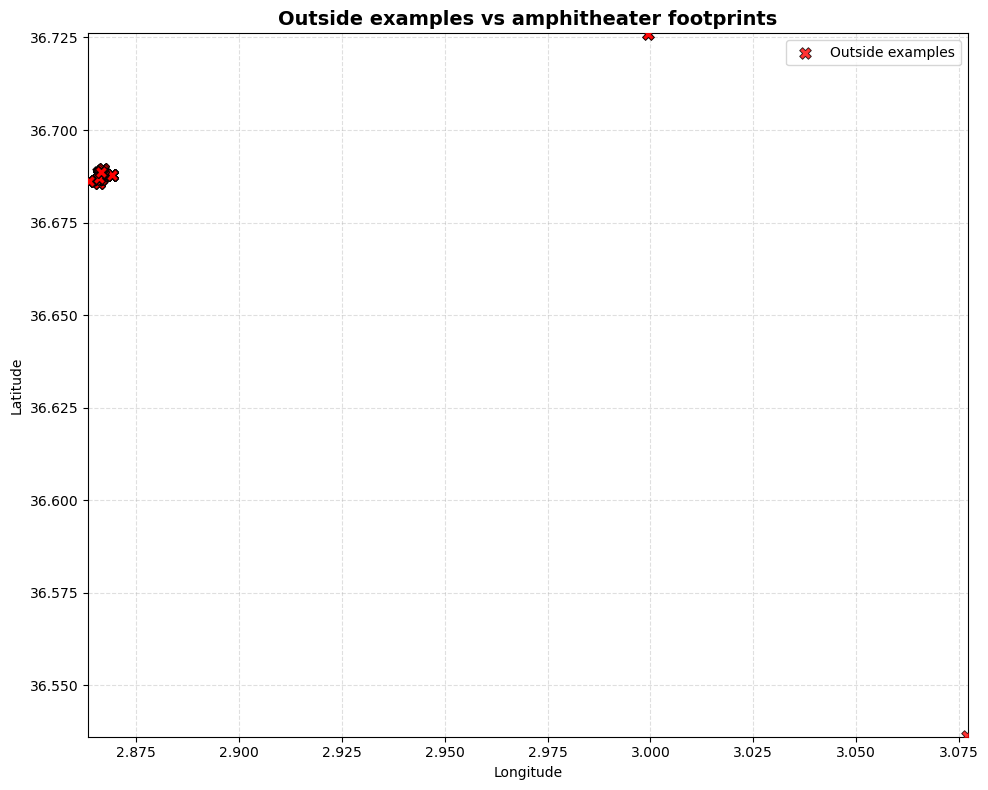

In [30]:
# Plot outside examples against amphitheater polygons
fig, ax = plt.subplots(figsize=(10, 8))

patches = []
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
for (_, corners), color in zip(amphi_corners.items(), colors):
    xy = np.array([(lon, lat) for lat, lon in corners])
    patches.append(Polygon(xy, closed=True))

ax.add_collection(PatchCollection(patches, facecolors=colors, alpha=0.15, zorder=1))

sns.scatterplot(
    data=df_outside,
    x='longitude_mean',
    y='latitude_mean',
    color='red',
    marker='X',
    s=70,
    alpha=0.8,
    edgecolor='black',
    ax=ax,
    zorder=5,
    label='Outside examples'
)

poly_lats = [c[0] for corners in amphi_corners.values() for c in corners]
poly_lons = [c[1] for corners in amphi_corners.values() for c in corners]
all_lats = poly_lats + df_outside['latitude_mean'].tolist()
all_lons = poly_lons + df_outside['longitude_mean'].tolist()

ax.set_xlim(min(all_lons) - 0.0002, max(all_lons) + 0.0002)
ax.set_ylim(min(all_lats) - 0.0002, max(all_lats) + 0.0002)

ax.set_title('Outside examples vs amphitheater footprints', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

cluster
-1      3
 0    753
 1    186
 2     33
 3     21
Name: count, dtype: int64


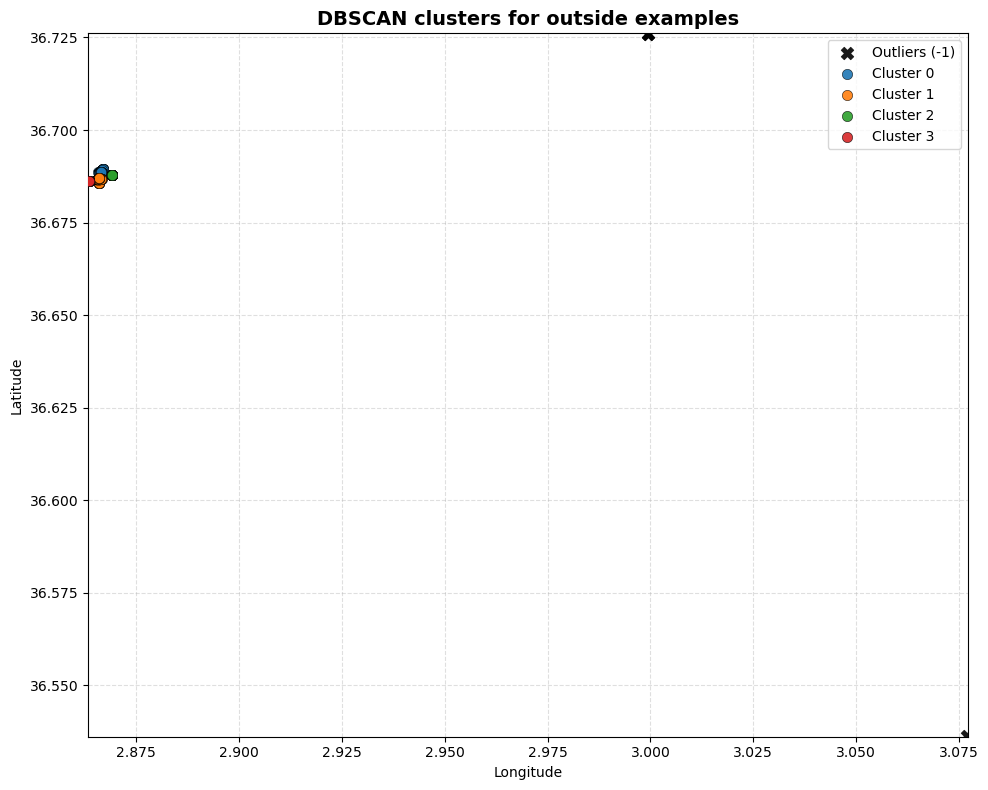

In [ ]:
# Cluster outside examples with DBSCAN and plot each cluster with a different color
from sklearn.cluster import DBSCAN

X_outside = df_outside[['latitude_mean', 'longitude_mean']].values

# Tune eps/min_samples if needed for your density scale
db_out = DBSCAN(eps=0.00008, min_samples=8)
df_outside['cluster'] = db_out.fit_predict(X_outside)

print(df_outside['cluster'].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(10, 8))

patches = []
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
for (_, corners), color in zip(amphi_corners.items(), colors):
    xy = np.array([(lon, lat) for lat, lon in corners])
    patches.append(Polygon(xy, closed=True))

ax.add_collection(PatchCollection(patches, facecolors=colors, alpha=0.12, zorder=1))

clusters = sorted(df_outside['cluster'].unique())
palette = sns.color_palette('tab10', n_colors=max(1, len([c for c in clusters if c != -1])))
color_map = {}
color_idx = 0
for c in clusters:
    if c == -1:
        color_map[c] = 'black'  # outliers
    else:
        color_map[c] = palette[color_idx]
        color_idx += 1

for c in clusters:
    subset = df_outside[df_outside['cluster'] == c]
    sns.scatterplot(
        data=subset,
        x='longitude_mean',
        y='latitude_mean',
        color=color_map[c],
        marker='X' if c == -1 else 'o',
        s=85 if c == -1 else 55,
        alpha=0.9,
        edgecolor='black',
        linewidth=0.4,
        ax=ax,
        zorder=6,
        label='Outliers (-1)' if c == -1 else f'Cluster {c}'
    )

poly_lats = [c[0] for corners in amphi_corners.values() for c in corners]
poly_lons = [c[1] for corners in amphi_corners.values() for c in corners]
all_lats = poly_lats + df_outside['latitude_mean'].tolist()
all_lons = poly_lons + df_outside['longitude_mean'].tolist()

ax.set_xlim(min(all_lons) - 0.0002, max(all_lons) + 0.0002)
ax.set_ylim(min(all_lats) - 0.0002, max(all_lats) + 0.0002)

ax.set_title('DBSCAN clusters for outside examples', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(loc='best', frameon=True)
plt.tight_layout()
plt.show()

In [34]:
df_outside['cluster'].value_counts()

cluster
 7     580
 5     146
 3      55
 12     33
 11     30
 9      21
 15     21
 1      15
-1      14
 10     13
 4      10
 0      10
 2      10
 6      10
 14     10
 8       9
 13      9
Name: count, dtype: int64

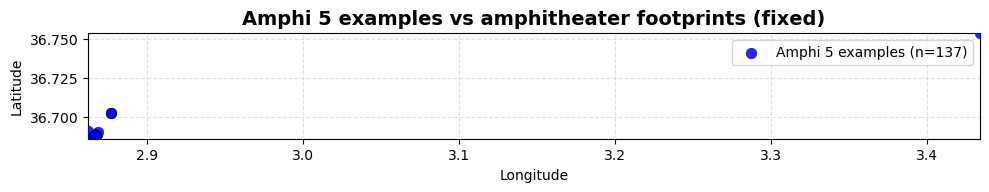

In [39]:
# Fixed plot for Amphi 5 examples against amphitheater polygons
df_a5_plot = df_a5.copy()
df_a5_plot['latitude_mean'] = pd.to_numeric(df_a5_plot['latitude_mean'], errors='coerce')
df_a5_plot['longitude_mean'] = pd.to_numeric(df_a5_plot['longitude_mean'], errors='coerce')
df_a5_plot = df_a5_plot.dropna(subset=['latitude_mean', 'longitude_mean'])

fig, ax = plt.subplots(figsize=(10, 8))

patches = []
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
for (_, corners), color in zip(amphi_corners.items(), colors):
    xy = np.array([(lon, lat) for lat, lon in corners])
    patches.append(Polygon(xy, closed=True))

ax.add_collection(PatchCollection(patches, facecolors=colors, alpha=0.15, zorder=1))

sns.scatterplot(
    data=df_a5_plot,
    x='longitude_mean',
    y='latitude_mean',
    color='blue',
    marker='o',
    s=60,
    alpha=0.85,
    edgecolor='black',
    linewidth=0.3,
    ax=ax,
    zorder=5,
    label=f'Amphi 5 examples (n={len(df_a5_plot)})'
)

poly_lats = [c[0] for corners in amphi_corners.values() for c in corners]
poly_lons = [c[1] for corners in amphi_corners.values() for c in corners]

if len(df_a5_plot) > 0:
    all_lats = poly_lats + df_a5_plot['latitude_mean'].to_list()
    all_lons = poly_lons + df_a5_plot['longitude_mean'].to_list()
else:
    all_lats = poly_lats
    all_lons = poly_lons

lat_pad = 0.0002
lon_pad = 0.0002
ax.set_xlim(min(all_lons) - lon_pad, max(all_lons) + lon_pad)
ax.set_ylim(min(all_lats) - lat_pad, max(all_lats) + lat_pad)
ax.set_aspect('equal', adjustable='box')

ax.set_title('Amphi 5 examples vs amphitheater footprints (fixed)', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, linestyle='--', alpha=0.4)
plt.legend(loc='best', frameon=True)
plt.tight_layout()
plt.show()

In [30]:
# Keep only cluster 1 instances
df_a2_clean = df_a2[df_a2['cluster'] == 3].copy()
# Optional: keep all non-cluster-1 points (including noise) for comparison
df_a2_noise = df_a2[df_a2['cluster'] != 3].copy()

# amphi 5 


In [31]:
# Build dataframe for Amphi 5 examples
df_a5 = df.loc[df['amphitheatre'] == 'Amphi 5', ['id', 'amphitheatre', 'latitude_mean', 'longitude_mean', 'is_outside']].copy()

df_a5['latitude_mean'] = pd.to_numeric(df_a5['latitude_mean'], errors='coerce')
df_a5['longitude_mean'] = pd.to_numeric(df_a5['longitude_mean'], errors='coerce')
df_a5 = df_a5.dropna(subset=['latitude_mean', 'longitude_mean'])

print(f"Amphi 5 examples: {len(df_a5)}")
df_a5.head()

Amphi 5 examples: 137


,id,amphitheatre,latitude_mean,longitude_mean,is_outside
11,11.0,Amphi 5,36.753994,3.433505,False
21,18.0,Amphi 5,36.688390,2.866721,False
22,19.0,Amphi 5,36.688390,2.866721,False
24,20.0,Amphi 5,36.688390,2.866721,False
25,21.0,Amphi 5,36.688390,2.866721,False


In [ ]:
# Amphi 5 polygon-focused plot (polygons always visible)
df_a5_plot = df_a5.copy()
df_a5_plot['latitude_mean'] = pd.to_numeric(df_a5_plot['latitude_mean'], errors='coerce')
df_a5_plot['longitude_mean'] = pd.to_numeric(df_a5_plot['longitude_mean'], errors='coerce')
df_a5_plot = df_a5_plot.dropna(subset=['latitude_mean', 'longitude_mean'])

fig, ax = plt.subplots(figsize=(10, 8))

patches = []
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
for (_, corners), color in zip(amphi_corners.items(), colors):
    xy = np.array([(lon, lat) for lat, lon in corners])
    patches.append(Polygon(xy, closed=True))

ax.add_collection(PatchCollection(patches, facecolors=colors, alpha=0.20, edgecolor='black', linewidth=0.8, zorder=1))

sns.scatterplot(
    data=df_a5_plot,
    x='longitude_mean',
    y='latitude_mean',
    color='blue',
    marker='o',
    s=40,
    alpha=0.75,
    edgecolor='black',
    linewidth=0.2,
    ax=ax,
    zorder=4,
    label=f'Amphi 5 examples (n={len(df_a5_plot)})'
)

# Keep limits around amphitheater polygons only
poly_lats = [c[0] for corners in amphi_corners.values() for c in corners]
poly_lons = [c[1] for corners in amphi_corners.values() for c in corners]
lat_pad = 0.00025
lon_pad = 0.00025

ax.set_xlim(min(poly_lons) - lon_pad, max(poly_lons) + lon_pad)
ax.set_ylim(min(poly_lats) - lat_pad, max(poly_lats) + lat_pad)
ax.set_aspect('equal', adjustable='box')

# Show how many points are inside visible window
in_view = df_a5_plot[
    (df_a5_plot['longitude_mean'] >= min(poly_lons) - lon_pad)
    & (df_a5_plot['longitude_mean'] <= max(poly_lons) + lon_pad)
    & (df_a5_plot['latitude_mean'] >= min(poly_lats) - lat_pad)
    & (df_a5_plot['latitude_mean'] <= max(poly_lats) + lat_pad)
]

ax.set_title(
    f'Amphi 5 vs amphi_corners | visible points: {len(in_view)}/{len(df_a5_plot)}',
    fontsize=13,
    fontweight='bold'
)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(loc='best', frameon=True)
plt.tight_layout()
plt.show()

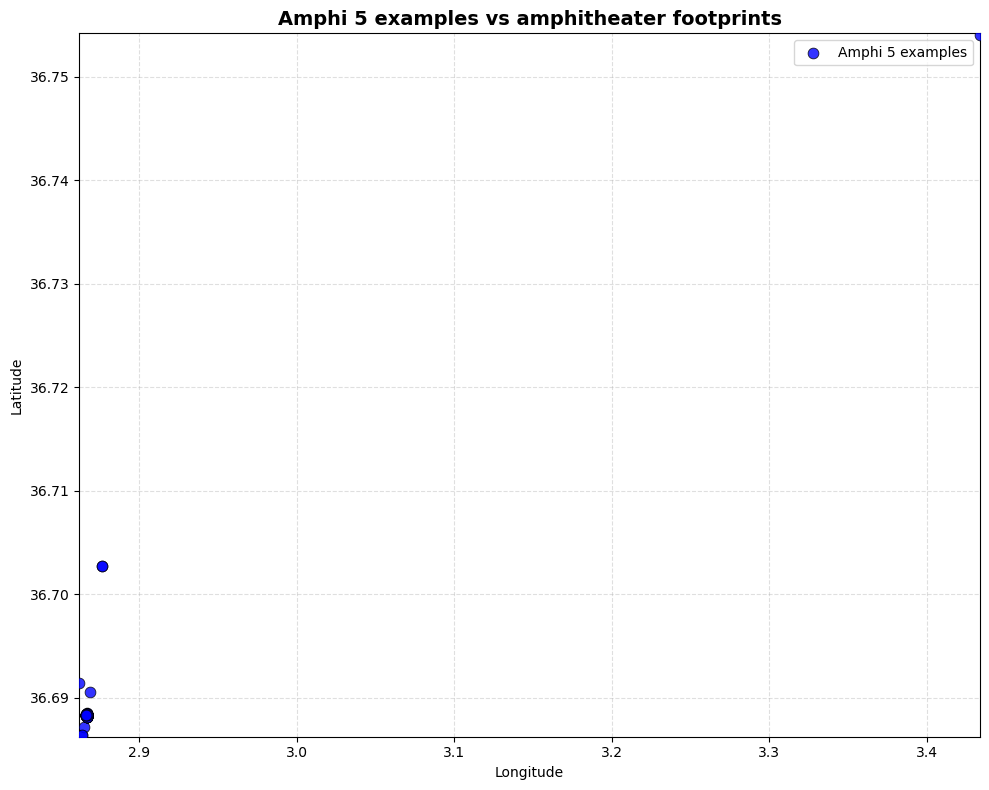

In [32]:
# Plot Amphi 5 examples against amphitheater polygons
fig, ax = plt.subplots(figsize=(10, 8))

patches = []
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
for (_, corners), color in zip(amphi_corners.items(), colors):
    xy = np.array([(lon, lat) for lat, lon in corners])
    patches.append(Polygon(xy, closed=True))

ax.add_collection(PatchCollection(patches, facecolors=colors, alpha=0.15, zorder=1))

sns.scatterplot(
    data=df_a5,
    x='longitude_mean',
    y='latitude_mean',
    color='blue',
    marker='o',
    s=60,
    alpha=0.8,
    edgecolor='black',
    ax=ax,
    zorder=5,
    label='Amphi 5 examples'
)

poly_lats = [c[0] for corners in amphi_corners.values() for c in corners]
poly_lons = [c[1] for corners in amphi_corners.values() for c in corners]
all_lats = poly_lats + df_a5['latitude_mean'].tolist()
all_lons = poly_lons + df_a5['longitude_mean'].tolist()

ax.set_xlim(min(all_lons) - 0.0002, max(all_lons) + 0.0002)
ax.set_ylim(min(all_lats) - 0.0002, max(all_lats) + 0.0002)

ax.set_title('Amphi 5 examples vs amphitheater footprints', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Cluster Amphi 5 examples using DBSCAN and plot colored clusters (-1 as outliers)
from sklearn.cluster import DBSCAN

X_a5 = df_a5[['latitude_mean', 'longitude_mean']].values

# Tune eps/min_samples if needed for your point density
db_a5 = DBSCAN(eps=0.00008, min_samples=8)
df_a5['cluster'] = db_a5.fit_predict(X_a5)

print(df_a5['cluster'].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(10, 8))

patches = []
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
for (_, corners), color in zip(amphi_corners.items(), colors):
    xy = np.array([(lon, lat) for lat, lon in corners])
    patches.append(Polygon(xy, closed=True))

ax.add_collection(PatchCollection(patches, facecolors=colors, alpha=0.12, zorder=1))

clusters = sorted(df_a5['cluster'].unique())
palette = sns.color_palette('tab10', n_colors=max(1, len([c for c in clusters if c != -1])))
color_map = {}
color_idx = 0
for c in clusters:
    if c == -1:
        color_map[c] = 'black'  # outliers
    else:
        color_map[c] = palette[color_idx]
        color_idx += 1

for c in clusters:
    subset = df_a5[df_a5['cluster'] == c]
    sns.scatterplot(
        data=subset,
        x='longitude_mean',
        y='latitude_mean',
        color=color_map[c],
        marker='X' if c == -1 else 'o',
        s=85 if c == -1 else 55,
        alpha=0.9,
        edgecolor='black',
        linewidth=0.4,
        ax=ax,
        zorder=6,
        label='Outliers (-1)' if c == -1 else f'Cluster {c}'
    )

poly_lats = [c[0] for corners in amphi_corners.values() for c in corners]
poly_lons = [c[1] for corners in amphi_corners.values() for c in corners]
all_lats = poly_lats + df_a5['latitude_mean'].tolist()
all_lons = poly_lons + df_a5['longitude_mean'].tolist()

ax.set_xlim(min(all_lons) - 0.0002, max(all_lons) + 0.0002)
ax.set_ylim(min(all_lats) - 0.0002, max(all_lats) + 0.0002)

ax.set_title('DBSCAN clusters for Amphi 5 examples', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(loc='best', frameon=True)
plt.tight_layout()
plt.show()